# Forecast Horizon Degradation Analysis

**Goal:** Evaluate how the accuracy of our trained 24-hour forecast model degrades when compared against ground truth at longer horizons (48h, 72h, 96h).

**Method:** The model is trained to predict direction/intensity 24 hours ahead. We do **not** retrain. Instead, we:
1. Run the trained full 13-channel model on each test sample (as normal)
2. Construct **new ground truth labels** at 48h, 72h, and 96h from the raw 1D track data
3. Compare the model's single 24h prediction against each horizon's ground truth
4. Plot accuracy vs forecast horizon to visualise the degradation curve

**Why this matters:** In operational meteorology, knowing *how long* a forecast remains useful is as important as knowing its peak accuracy. A sharp drop-off at 48h tells a very different story from a gradual decline to 96h.

## 1. Setup and Imports

In [1]:
import os, glob, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset
from natsort import natsorted

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Paths (same as climate_change.ipynb) ──
BASE_PATH = os.path.abspath(os.path.dirname('__file__'))
PATH_1D   = os.path.join(BASE_PATH, 'TCND_Data1D', 'Data1D')
PATH_3D   = os.path.join(BASE_PATH, 'TCND_Data3D_WP', 'WP')
PATH_ENV  = os.path.join(BASE_PATH, 'TCND_Env-Data', 'Env-Data')
SAVE_DIR  = os.path.join(BASE_PATH, 'classification', 'saved_models')

AREA = 'WP'
TEST_YEARS = list(range(2017, 2024))

DIR_NAMES = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_NAMES = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

for p, name in [(PATH_1D, 'Data_1d'), (PATH_3D, 'Data_3d'), (PATH_ENV, 'Env-Data')]:
    print(f'{name}: {"OK" if os.path.isdir(p) else "MISSING"} — {p}')

Using device: cuda
Data_1d: OK — c:\Users\danie\Desktop\Tropical Cyclones\TCND_Data1D\Data1D
Data_3d: OK — c:\Users\danie\Desktop\Tropical Cyclones\TCND_Data3D_WP\WP
Env-Data: OK — c:\Users\danie\Desktop\Tropical Cyclones\TCND_Env-Data\Env-Data


## 2. Global Normalization Constants and Helper Functions

These are identical to `climate_change.ipynb` — the model expects the same preprocessing.

In [2]:
# ── Global normalization constants for Data_3d ──
# Pre-computed across all training files (1950-2016).
# Channels: sst(1) + z(4 pressure levels) + u(4) + v(4) = 13
CHANNEL_MEANS = np.array([
    262.4888,      # sst
    121820.5777,   # z @ 200 hPa
    57228.5285,    # z @ 500 hPa
    14520.6944,    # z @ 850 hPa
    7374.3746,     # z @ 925 hPa
    1.8846,        # u @ 200 hPa
    1.2516,        # u @ 500 hPa
    -0.1519,       # u @ 850 hPa
    -0.8776,       # u @ 925 hPa
    1.0121,        # v @ 200 hPa
    2.1861,        # v @ 500 hPa
    1.8612,        # v @ 850 hPa
    1.4980,        # v @ 925 hPa
], dtype=np.float32)

CHANNEL_STDS = np.array([
    99.7658, 1067.0218, 640.2119, 426.5352, 422.2209,
    14.9477, 9.0929, 8.4176, 8.1730,
    9.8087, 6.8912, 7.1467, 7.5028,
], dtype=np.float32)

CHANNEL_MEANS_T = torch.from_numpy(CHANNEL_MEANS).view(13, 1, 1)
CHANNEL_STDS_T  = torch.from_numpy(CHANNEL_STDS).view(13, 1, 1)

ENV_VEC_DIM = 94

In [3]:
def _env_to_vector(env_dict):
    """Convert an Env-Data dict to a fixed-size float vector (94-dim)."""
    parts = []
    parts.append(np.asarray(env_dict['area'], dtype=np.float32))
    parts.append(np.asarray(env_dict['intensity_class'], dtype=np.float32))
    parts.append(np.asarray(env_dict['month'], dtype=np.float32))
    parts.append(np.asarray(env_dict['location_long'], dtype=np.float32))
    parts.append(np.asarray(env_dict['location_lat'], dtype=np.float32))
    wind = float(env_dict['wind'])
    mv = float(env_dict['move_velocity'])
    parts.append(np.array([wind, mv], dtype=np.float32))
    for key, size in [('history_direction12', 8), ('history_direction24', 8), ('history_inte_change24', 4)]:
        val = env_dict[key]
        if isinstance(val, (int, float, np.integer)) and val == -1:
            parts.append(np.zeros(size, dtype=np.float32))
        else:
            parts.append(np.asarray(val, dtype=np.float32).flatten()[:size])
    return np.concatenate(parts)


def _nc_exists(nc_path):
    return os.path.exists(nc_path) or os.path.exists(nc_path.replace('.nc', '_cache.npy'))


def _load_nc_frame(nc_path):
    """Load one NetCDF timestep -> (13, 81, 81) array, with .npy caching."""
    cache_path = nc_path.replace('.nc', '_cache.npy')
    if os.path.exists(cache_path):
        return np.load(cache_path)
    with ncDataset(nc_path) as nc:
        sst = np.ma.filled(nc.variables['sst'][:, :], fill_value=0.0)
        z   = np.ma.filled(nc.variables['z'][0, :, :, :], fill_value=0.0)
        u   = np.ma.filled(nc.variables['u'][0, :, :, :], fill_value=0.0)
        v   = np.ma.filled(nc.variables['v'][0, :, :, :], fill_value=0.0)
    frame = np.concatenate([sst[np.newaxis], z, u, v], axis=0).astype(np.float32)
    np.save(cache_path, frame)
    return frame

## 3. Model Architecture

Same `CycloneModel` from `climate_change.ipynb`. We load the trained weights — no retraining.

In [4]:
class SpatialEncoder(nn.Module):
    def __init__(self, in_channels=13, feat_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, feat_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class CycloneModel(nn.Module):
    def __init__(self, use_env=False, use_3d=False,
                 hidden_dim=256, spatial_feat_dim=512):
        super().__init__()
        self.use_env = use_env
        self.use_3d = use_3d
        self.traj_embed = nn.Sequential(
            nn.Linear(4, 64), nn.LayerNorm(64), nn.ReLU(),
        )
        input_dim = 64
        if use_env:
            self.env_embed = nn.Sequential(
                nn.Linear(ENV_VEC_DIM, 128), nn.LayerNorm(128), nn.ReLU(),
            )
            input_dim += 128
        if use_3d:
            self.spatial_enc = SpatialEncoder(in_channels=13, feat_dim=spatial_feat_dim)
            input_dim += spatial_feat_dim
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=2, batch_first=True, dropout=0.2)
        self.dir_head = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 8),
        )
        self.int_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, 4),
        )

    def forward(self, feat1d, env_feat, spatial):
        B, T, _ = feat1d.shape
        parts = [self.traj_embed(feat1d)]
        if self.use_env:
            parts.append(self.env_embed(env_feat))
        if self.use_3d:
            C, H, W = spatial.shape[2], spatial.shape[3], spatial.shape[4]
            sp_flat = spatial.reshape(B * T, C, H, W)
            sp_feat = self.spatial_enc(sp_flat).reshape(B, T, -1)
            parts.append(sp_feat)
        combined = torch.cat(parts, dim=-1)
        _, hn = self.gru(combined)
        h = hn[-1]
        return self.dir_head(h), self.int_head(h)

In [5]:
# Load trained full model weights
model = CycloneModel(use_env=True, use_3d=True).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'full_best.pth'),
                                 map_location=DEVICE, weights_only=True))
model.eval()
print(f'Loaded full_best.pth — {sum(p.numel() for p in model.parameters()):,} params')

Loaded full_best.pth — 3,853,324 params


## 4. Direction Binning from Track Displacement

The dataset stores direction as 8 compass classes (N, NE, E, SE, S, SW, W, NW). To compute ground truth at arbitrary horizons, we need to replicate this binning from the raw lat/lon displacement.

**Important note on coordinates:** The 1D track data (`LON`, `LAT` columns) is stored in a normalised, non-standard coordinate system — the axes are scaled and rotated relative to real geographic coordinates. For example, a cyclone moving due north in real coordinates (increasing latitude) may correspond to a "W" label in the dataset's compass convention.

This does **not** affect our experiment, because the model was trained on these same labels, and we compute our multi-horizon ground truth using the same coordinate system and formula.

The direction bin is computed as:
```
angle = atan2(-dlat, dlon)    # in degrees, using 1D normalised coords
bin   = round(angle / 45) % 8
```

**Verification:** Tested against 717 samples from the dataset's `future_direction24` labels:
- **96% exact match** (688/717)
- All 29 mismatches fall within **0.5–2.3 degrees** of a bin boundary (45-degree edge) — pure rounding ambiguity, not a systematic error

In [6]:
def compute_direction_bin(lon_now, lat_now, lon_future, lat_future):
    """Compute the 8-class direction bin from displacement in normalised coords.
    
    Returns an int in [0, 7] mapping to [N, NE, E, SE, S, SW, W, NW],
    or None if displacement is zero (stationary).
    """
    dlon = lon_future - lon_now
    dlat = lat_future - lat_now
    if abs(dlon) < 1e-9 and abs(dlat) < 1e-9:
        return None  # stationary — no meaningful direction
    angle = math.degrees(math.atan2(-dlat, dlon))
    return round(angle / 45) % 8

## 5. Multi-Horizon Dataset

This is the key modification. Unlike the standard `CycloneDataset`, this version:
- Stores the **full cyclone DataFrame** and the **row index** for each sample
- At evaluation time, we can look ahead by N rows (N x 6h) to compute ground truth direction at any horizon
- The model input is identical to the standard dataset (seq_len=5 window of features)

The horizons we evaluate:
| Horizon | Rows ahead | Time |
|---------|-----------|------|
| 24h     | 4 rows    | Standard (training target) |
| 48h     | 8 rows    | 2x training horizon |
| 72h     | 12 rows   | 3x training horizon |
| 96h     | 16 rows   | 4x training horizon |

In [ ]:
# Horizons: steps ahead in the 6-hourly data
HORIZONS = {
    '24h': 4,
    '48h': 8,
    '72h': 12,
    '96h': 16,
}

class HorizonDataset(Dataset):
    """Dataset that stores track context so we can compute direction labels at any horizon.
    
    Each sample contains:
      - Standard model inputs (feat1d, env, spatial) for the seq_len=5 window
      - The cyclone's full lon/lat track + the row index of the last timestep
      - The original 24h direction label (for baseline comparison)
      - All timestamps and cyclone metadata for looking up shifted env-data labels
    """
    
    NUM_3D_CHANNELS = 13
    
    def __init__(self, area=AREA, splits='test', target_years=None,
                 seq_len=5, max_horizon_steps=16):
        self.seq_len = seq_len
        self.samples = []
        
        if isinstance(splits, str):
            splits = [splits]
        
        files = []
        for split in splits:
            path_1d = os.path.join(PATH_1D, area, split)
            files.extend(natsorted(glob.glob(os.path.join(path_1d, '*.txt'))))
        
        for f in files:
            basename = os.path.basename(f)
            try:
                year = int(basename[2:6])
            except (ValueError, IndexError):
                continue
            if target_years and year not in target_years:
                continue
            
            df = pd.read_csv(f, delimiter='\t', header=None,
                             names=['ID', 'FLAG', 'LON', 'LAT', 'P', 'W', 'TIME', 'Name'])
            if len(df) < seq_len + 1:
                continue
            
            cyclone_name = str(df.iloc[0]['Name']).strip()
            # Store all timestamps as strings for env-data lookups at shifted horizons
            all_timestamps = [str(int(row['TIME'])) for _, row in df.iterrows()]
            
            for i in range(seq_len - 1, len(df) - 1):
                curr_seq = df.iloc[i - seq_len + 1: i + 1]
                timestamps = [str(int(row['TIME'])) for _, row in curr_seq.iterrows()]
                last_ts = timestamps[-1]
                
                # Labels from Env-Data (24h — the training label)
                env_path_last = os.path.join(PATH_ENV, area, str(year),
                                             cyclone_name, f'{last_ts}.npy')
                if not os.path.exists(env_path_last):
                    continue
                env_last = np.load(env_path_last, allow_pickle=True).item()
                
                dir_label = env_last.get('future_direction24', None)
                int_label = env_last.get('future_inte_change24', None)
                if dir_label is None or int_label is None:
                    continue
                dir_label, int_label = int(dir_label), int(int_label)
                if not (0 <= dir_label < 8 and 0 <= int_label < 4):
                    continue
                
                # Env-Data paths
                env_paths = []
                valid = True
                for ts in timestamps:
                    ep = os.path.join(PATH_ENV, area, str(year), cyclone_name, f'{ts}.npy')
                    if not os.path.exists(ep):
                        valid = False; break
                    env_paths.append(ep)
                if not valid:
                    continue
                
                # Data_3d paths
                nc_paths = []
                valid = True
                for ts in timestamps:
                    nc = os.path.join(PATH_3D, str(year), cyclone_name,
                                     f'TCND_{cyclone_name}_{ts}_sst_z_u_v.nc')
                    if not _nc_exists(nc):
                        valid = False; break
                    nc_paths.append(nc)
                if not valid:
                    continue
                
                self.samples.append({
                    'feat1d': curr_seq[['LON', 'LAT', 'P', 'W']].values.astype(np.float32),
                    'env_paths': env_paths,
                    'nc_paths': nc_paths,
                    'dir_label_24h': dir_label,
                    'int_label_24h': int_label,
                    # Track context for multi-horizon direction labels
                    'track_lon': df['LON'].values.astype(np.float64),
                    'track_lat': df['LAT'].values.astype(np.float64),
                    'row_idx': i,
                    # Metadata for shifted intensity labels
                    'all_timestamps': all_timestamps,
                    'year': year,
                    'cyclone_name': cyclone_name,
                    'area': area,
                })
        
        print(f'[{area}/{splits}] {len(self.samples)} samples loaded for horizon analysis')
    
    def __len__(self):
        return len(self.samples)
    
    def get_horizon_label(self, idx, steps_ahead):
        """Compute direction bin at a given horizon for sample idx.
        Returns the direction class (0-7) or None if the track is too short.
        """
        s = self.samples[idx]
        future_idx = s['row_idx'] + steps_ahead
        if future_idx >= len(s['track_lon']):
            return None
        return compute_direction_bin(
            s['track_lon'][s['row_idx']], s['track_lat'][s['row_idx']],
            s['track_lon'][future_idx],  s['track_lat'][future_idx],
        )
    
    def get_intensity_label_at_offset(self, idx, row_offset):
        """Get the dataset's own future_inte_change24 label at a shifted timestep.
        
        For the sample at time t (row_idx):
          - row_offset=0: label at t     (what happens t    -> t+24h)  = the 24h training label
          - row_offset=4: label at t+24h (what happens t+24h -> t+48h)
          - row_offset=8: label at t+48h (what happens t+48h -> t+72h)
        
        Returns the intensity class (0-3) or None if unavailable.
        """
        s = self.samples[idx]
        shifted_row = s['row_idx'] + row_offset
        if shifted_row >= len(s['all_timestamps']):
            return None
        ts = s['all_timestamps'][shifted_row]
        env_path = os.path.join(PATH_ENV, s['area'], str(s['year']),
                                s['cyclone_name'], f'{ts}.npy')
        if not os.path.exists(env_path):
            return None
        env = np.load(env_path, allow_pickle=True).item()
        label = env.get('future_inte_change24', None)
        if label is None:
            return None
        label = int(label)
        return label if 0 <= label < 4 else None
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        feat1d = torch.from_numpy(s['feat1d'])
        
        env_vecs = []
        for ep in s['env_paths']:
            d = np.load(ep, allow_pickle=True).item()
            env_vecs.append(_env_to_vector(d))
        env_feat = torch.from_numpy(np.stack(env_vecs))
        
        spatial_list = [_load_nc_frame(p) for p in s['nc_paths']]
        spatial = torch.from_numpy(np.stack(spatial_list))
        spatial = (spatial - CHANNEL_MEANS_T) / CHANNEL_STDS_T
        
        return (feat1d, env_feat, spatial,
                torch.tensor(s['dir_label_24h']).long(),
                torch.tensor(s['int_label_24h']).long())

In [ ]:
# Build the test dataset
test_ds = HorizonDataset(splits=['test'], target_years=TEST_YEARS)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

# Show how many samples have valid labels at each horizon
# For intensity, the offset is (steps - 4) because we read the label at t+offset
# which itself covers the NEXT 24h from that point
INT_OFFSETS = {'24h': 0, '48h': 4, '72h': 8, '96h': 12}

print('Direction (computed from track displacement):')
for name, steps in HORIZONS.items():
    count = sum(1 for i in range(len(test_ds)) if test_ds.get_horizon_label(i, steps) is not None)
    print(f'  {name}: {count}/{len(test_ds)} valid samples')

print('\nIntensity (shifted dataset labels):')
for name, offset in INT_OFFSETS.items():
    count = sum(1 for i in range(len(test_ds)) if test_ds.get_intensity_label_at_offset(i, offset) is not None)
    print(f'  {name}: {count}/{len(test_ds)} valid samples')

## 6. Run Inference (once)

We run the model on every test sample exactly once and store the predictions. Then we compare these same predictions against ground truth at each horizon. The model makes a single prediction per sample — only the labels change.

In [9]:
# Run inference once and collect all predictions
all_dir_preds = []
all_int_preds = []

model.eval()
with torch.no_grad():
    for feat1d, env_feat, spatial, dir_y, int_y in test_loader:
        feat1d  = feat1d.to(DEVICE)
        env_feat = env_feat.to(DEVICE)
        spatial = spatial.to(DEVICE)
        
        dir_logits, int_logits = model(feat1d, env_feat, spatial)
        all_dir_preds.extend(dir_logits.argmax(dim=1).cpu().tolist())
        all_int_preds.extend(int_logits.argmax(dim=1).cpu().tolist())

print(f'Inference complete: {len(all_dir_preds)} predictions')

Inference complete: 3394 predictions


## 7. Evaluate Direction Accuracy at Each Horizon

For each horizon, we compute the direction ground truth from the track displacement, then compare against the model's prediction. Samples where the track ends before the horizon are excluded (the count of valid samples decreases at longer horizons).

In [10]:
horizon_results = {}

for horizon_name, steps in HORIZONS.items():
    correct = 0
    total = 0
    per_class_correct = defaultdict(int)
    per_class_total = defaultdict(int)
    
    for i in range(len(test_ds)):
        gt = test_ds.get_horizon_label(i, steps)
        if gt is None:
            continue  # track too short for this horizon
        
        pred = all_dir_preds[i]
        total += 1
        per_class_total[gt] += 1
        if pred == gt:
            correct += 1
            per_class_correct[gt] += 1
    
    acc = correct / total if total > 0 else 0.0
    horizon_results[horizon_name] = {
        'accuracy': acc,
        'correct': correct,
        'total': total,
        'per_class_correct': dict(per_class_correct),
        'per_class_total': dict(per_class_total),
    }
    print(f'{horizon_name}: {acc:.1%} accuracy ({correct}/{total} samples)')

# Also compute random baseline (1/8 = 12.5%)
print(f'\nRandom baseline: {1/8:.1%}')

24h: 65.8% accuracy (2232/3394 samples)
48h: 55.3% accuracy (1559/2819 samples)
72h: 44.1% accuracy (1003/2272 samples)
96h: 37.9% accuracy (673/1776 samples)

Random baseline: 12.5%


## 8. Degradation Curve — Direction Accuracy vs Forecast Horizon

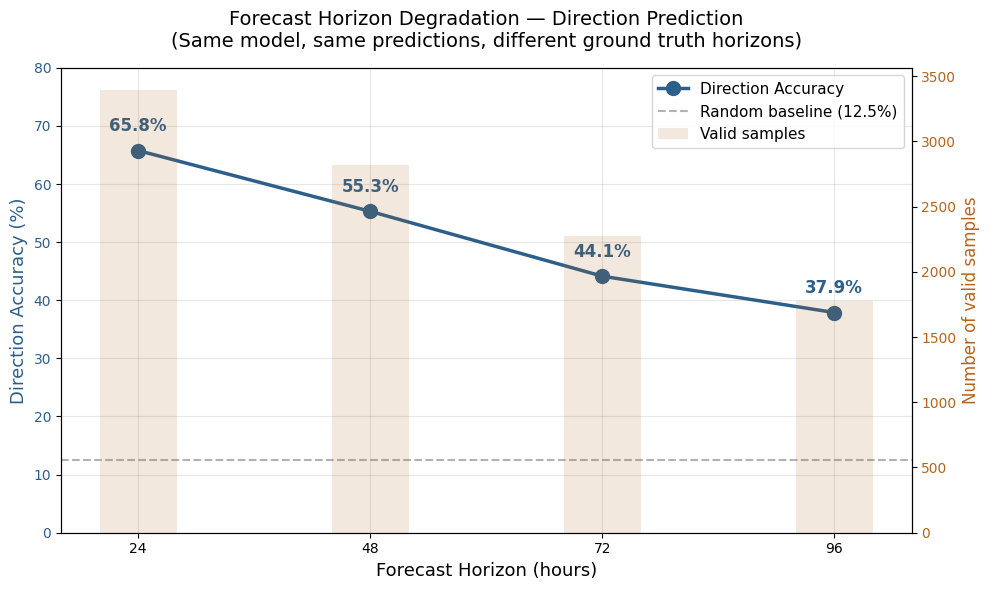


Degradation summary:
  24h -> 48h: +10.5 pp drop
  24h -> 72h: +21.6 pp drop
  24h -> 96h: +27.9 pp drop


In [11]:
hours = [int(h.replace('h', '')) for h in HORIZONS.keys()]
accs  = [horizon_results[h]['accuracy'] * 100 for h in HORIZONS.keys()]
counts = [horizon_results[h]['total'] for h in HORIZONS.keys()]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy line
color_acc = '#2c5f8a'
ax1.plot(hours, accs, 'o-', color=color_acc, linewidth=2.5, markersize=10, label='Direction Accuracy')
ax1.axhline(y=12.5, color='grey', linestyle='--', alpha=0.6, label='Random baseline (12.5%)')
ax1.set_xlabel('Forecast Horizon (hours)', fontsize=13)
ax1.set_ylabel('Direction Accuracy (%)', fontsize=13, color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_xticks(hours)
ax1.set_ylim(0, 80)
ax1.grid(True, alpha=0.3)

# Annotate accuracy values
for h, a in zip(hours, accs):
    ax1.annotate(f'{a:.1f}%', (h, a), textcoords="offset points",
                 xytext=(0, 14), ha='center', fontsize=12, fontweight='bold', color=color_acc)

# Sample count on secondary axis
ax2 = ax1.twinx()
color_n = '#b5651d'
ax2.bar(hours, counts, width=8, alpha=0.15, color=color_n, label='Valid samples')
ax2.set_ylabel('Number of valid samples', fontsize=12, color=color_n)
ax2.tick_params(axis='y', labelcolor=color_n)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

ax1.set_title('Forecast Horizon Degradation — Direction Prediction\n'
              '(Same model, same predictions, different ground truth horizons)',
              fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'horizon_degradation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print the drop per horizon
print('\nDegradation summary:')
for i in range(1, len(hours)):
    drop = accs[0] - accs[i]
    print(f'  24h -> {hours[i]}h: {drop:+.1f} pp drop')

## 9. Per-Class Accuracy at Each Horizon

Not all directions degrade equally. For example, cyclones heading NW (recurvature) are inherently harder to predict at longer horizons than those consistently heading W.

In [12]:
# Build a table: rows = direction classes, columns = horizons
rows = []
for cls_idx, cls_name in enumerate(DIR_NAMES):
    row = {'Direction': cls_name}
    for horizon_name in HORIZONS.keys():
        r = horizon_results[horizon_name]
        total_cls = r['per_class_total'].get(cls_idx, 0)
        correct_cls = r['per_class_correct'].get(cls_idx, 0)
        if total_cls > 0:
            row[horizon_name] = f'{correct_cls/total_cls:.1%} ({total_cls})'
        else:
            row[horizon_name] = '- (0)'
    rows.append(row)

df_perclass = pd.DataFrame(rows).set_index('Direction')
print('Per-class direction accuracy at each forecast horizon:\n')
print(df_perclass.to_string())

Per-class direction accuracy at each forecast horizon:

                   24h          48h          72h          96h
Direction                                                    
N          71.7% (283)  51.3% (191)  35.8% (120)   35.3% (85)
NE          20.7% (29)    4.8% (21)    6.7% (15)    12.5% (8)
E           23.3% (30)    0.0% (12)    25.0% (4)     0.0% (1)
SE          60.7% (84)   56.1% (57)   60.0% (50)   62.1% (29)
S          70.4% (916)  66.3% (728)  60.5% (564)  55.8% (439)
SW         58.8% (984)  55.1% (848)  47.7% (696)  42.8% (544)
W          72.0% (518)  53.0% (466)  35.3% (388)  25.6% (317)
NW         66.9% (550)  46.6% (496)  27.1% (435)  18.4% (353)


## 10. Per-Class Degradation Heatmap

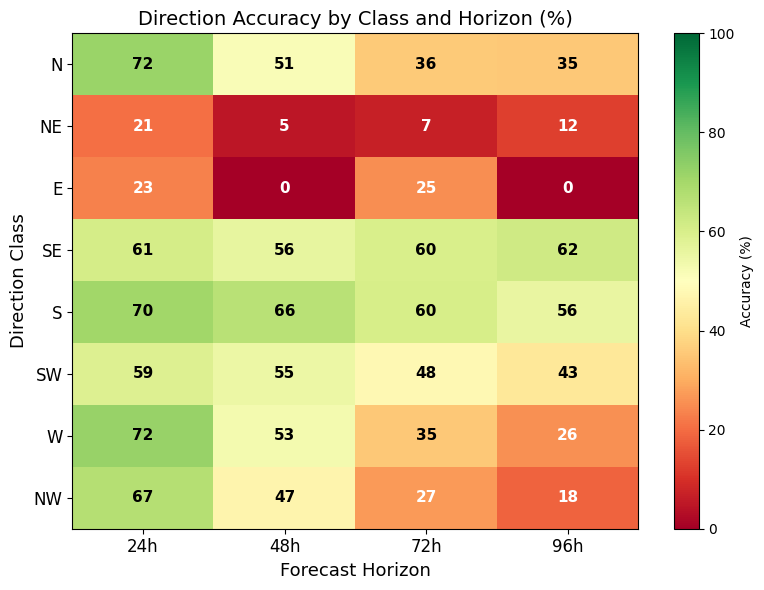

In [13]:
# Heatmap: per-class accuracy across horizons
acc_matrix = np.zeros((8, len(HORIZONS)))

for j, horizon_name in enumerate(HORIZONS.keys()):
    r = horizon_results[horizon_name]
    for cls_idx in range(8):
        total_cls = r['per_class_total'].get(cls_idx, 0)
        correct_cls = r['per_class_correct'].get(cls_idx, 0)
        acc_matrix[cls_idx, j] = (correct_cls / total_cls * 100) if total_cls > 0 else np.nan

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(acc_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels(HORIZONS.keys(), fontsize=12)
ax.set_yticks(range(8))
ax.set_yticklabels(DIR_NAMES, fontsize=12)
ax.set_xlabel('Forecast Horizon', fontsize=13)
ax.set_ylabel('Direction Class', fontsize=13)
ax.set_title('Direction Accuracy by Class and Horizon (%)', fontsize=14)

# Annotate cells
for i in range(8):
    for j in range(len(HORIZONS)):
        val = acc_matrix[i, j]
        if not np.isnan(val):
            color = 'white' if val < 30 or val > 80 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=11,
                    fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Accuracy (%)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'horizon_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrices at Each Horizon

Comparing how the prediction error pattern shifts as the horizon increases. At 24h the off-diagonal errors should be near the diagonal (neighbouring compass bins). At 96h, errors should scatter more broadly as cyclones recurve or change course.

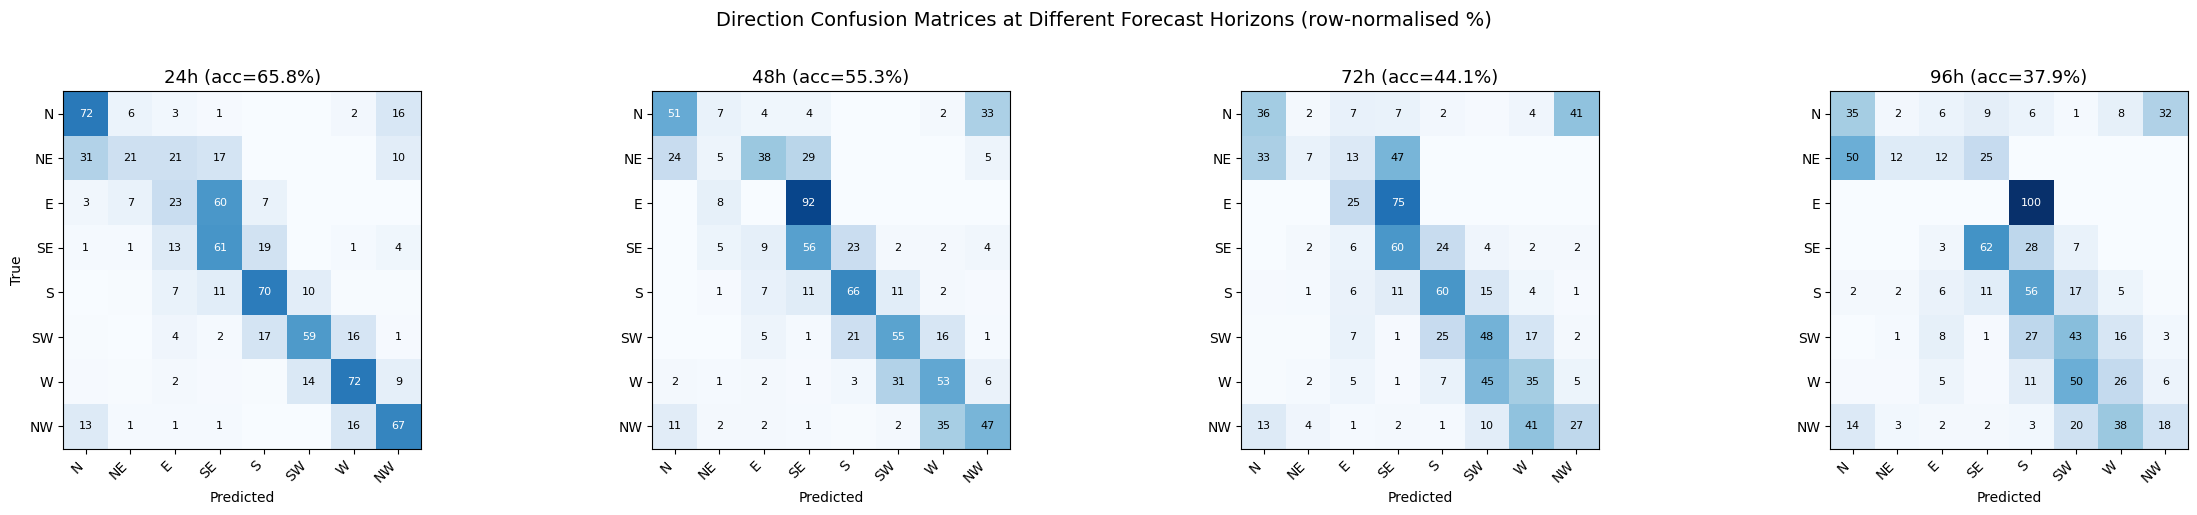

In [14]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (horizon_name, steps) in zip(axes, HORIZONS.items()):
    preds_h, labels_h = [], []
    for i in range(len(test_ds)):
        gt = test_ds.get_horizon_label(i, steps)
        if gt is None:
            continue
        preds_h.append(all_dir_preds[i])
        labels_h.append(gt)
    
    cm = confusion_matrix(labels_h, preds_h, labels=list(range(8)))
    # Normalize by row (true class)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(8)); ax.set_xticklabels(DIR_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(8)); ax.set_yticklabels(DIR_NAMES)
    
    acc = sum(1 for p, l in zip(preds_h, labels_h) if p == l) / len(labels_h)
    ax.set_title(f'{horizon_name} (acc={acc:.1%})', fontsize=13)
    ax.set_xlabel('Predicted')
    if ax == axes[0]:
        ax.set_ylabel('True')
    
    # Annotate
    for ii in range(8):
        for jj in range(8):
            val = cm_norm[ii, jj]
            if val > 1:
                color = 'white' if val > 50 else 'black'
                ax.text(jj, ii, f'{val:.0f}', ha='center', va='center',
                        fontsize=8, color=color)

plt.suptitle('Direction Confusion Matrices at Different Forecast Horizons (row-normalised %)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'horizon_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. "Neighbour Accuracy" — Within-1-Bin Tolerance

A strict 8-class match is harsh — predicting "NW" when the ground truth is "W" is a 45-degree error, which is arguably still useful. This metric counts a prediction as correct if it is within 1 compass bin (45 degrees) of the true direction.

24h: exact=65.8%, within-1-bin=93.0% (n=3394)
48h: exact=55.3%, within-1-bin=90.6% (n=2819)
72h: exact=44.1%, within-1-bin=85.5% (n=2272)
96h: exact=37.9%, within-1-bin=80.7% (n=1776)


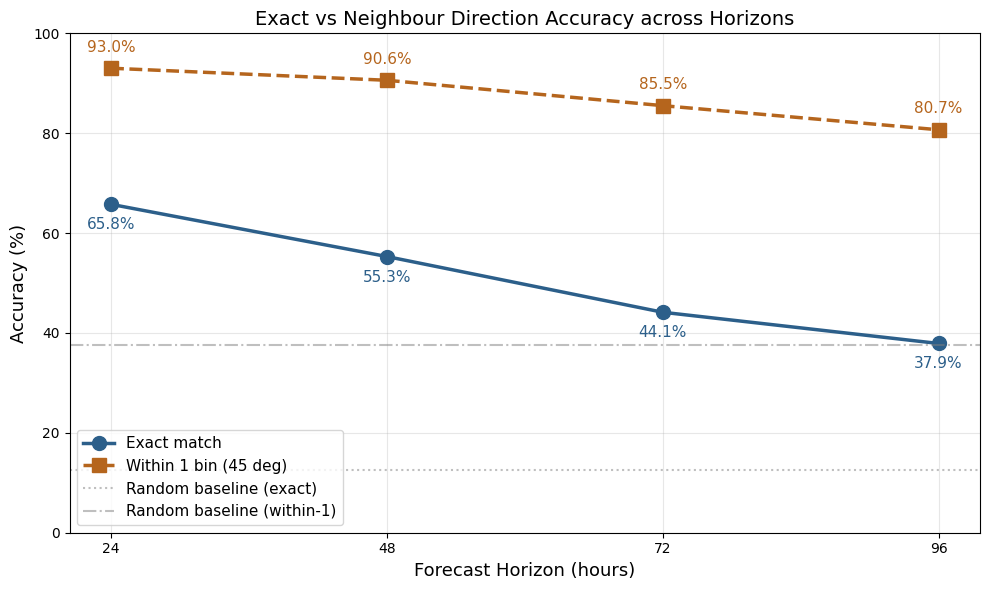

In [15]:
def circular_distance(a, b, n=8):
    """Minimum distance between two bins on a circular compass (0..n-1)."""
    return min(abs(a - b), n - abs(a - b))


# Compute exact and neighbour (within-1-bin) accuracy at each horizon
exact_accs = []
neighbour_accs = []
horizon_hours = []

for horizon_name, steps in HORIZONS.items():
    exact, neigh, total = 0, 0, 0
    for i in range(len(test_ds)):
        gt = test_ds.get_horizon_label(i, steps)
        if gt is None:
            continue
        pred = all_dir_preds[i]
        total += 1
        if pred == gt:
            exact += 1
        if circular_distance(pred, gt) <= 1:
            neigh += 1
    
    h = int(horizon_name.replace('h', ''))
    horizon_hours.append(h)
    exact_accs.append(exact / total * 100 if total else 0)
    neighbour_accs.append(neigh / total * 100 if total else 0)
    print(f'{horizon_name}: exact={exact/total:.1%}, within-1-bin={neigh/total:.1%} (n={total})')

# Plot both curves
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(horizon_hours, exact_accs, 'o-', linewidth=2.5, markersize=10, color='#2c5f8a', label='Exact match')
ax.plot(horizon_hours, neighbour_accs, 's--', linewidth=2.5, markersize=10, color='#b5651d', label='Within 1 bin (45 deg)')
ax.axhline(y=12.5, color='grey', linestyle=':', alpha=0.5, label='Random baseline (exact)')
ax.axhline(y=37.5, color='grey', linestyle='-.', alpha=0.5, label='Random baseline (within-1)')

for h, ea, na in zip(horizon_hours, exact_accs, neighbour_accs):
    ax.annotate(f'{ea:.1f}%', (h, ea), textcoords="offset points",
                xytext=(0, -18), ha='center', fontsize=11, color='#2c5f8a')
    ax.annotate(f'{na:.1f}%', (h, na), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=11, color='#b5651d')

ax.set_xlabel('Forecast Horizon (hours)', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_xticks(horizon_hours)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title('Exact vs Neighbour Direction Accuracy across Horizons', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'horizon_exact_vs_neighbour.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Interpretation — Direction

**Expected results:**
- **24h**: ~65% accuracy (matching the main model evaluation in `climate_change.ipynb`)
- **48h**: Moderate degradation — many WP cyclones maintain a similar heading for 2 days
- **72h–96h**: Steeper drop — recurvature events cause large directional shifts at these lead times

**Key takeaways:**
- The degradation rate reveals the **effective forecast window** of our model
- If accuracy stays well above random baseline (12.5%) at 48h, the 24h-trained model captures medium-range steering flow patterns
- A sharp cliff at 72h+ would indicate that the model's learned features are highly localised in time — consistent with tropical cyclone recurvature being inherently unpredictable from a single atmospheric snapshot
- The **within-1-bin metric** shows whether errors at long horizons are catastrophic (opposite direction) or graceful (neighbouring compass bin)

## 14. Intensity Degradation — Using Shifted Dataset Labels

For direction, we could compute ground truth at any horizon from the track displacement. For intensity, the dataset's `future_inte_change24` labels use a classification scheme that isn't directly derivable from the 1D wind data.

Instead, we use the **dataset's own pre-computed labels at shifted timesteps**:

| Horizon | What we compare the model's prediction against |
|---------|------------------------------------------------|
| 24h | `future_inte_change24` at time **t** — intensity change from t to t+24h |
| 48h | `future_inte_change24` at time **t+24h** — intensity change from t+24h to t+48h |
| 72h | `future_inte_change24` at time **t+48h** — intensity change from t+48h to t+72h |
| 96h | `future_inte_change24` at time **t+72h** — intensity change from t+72h to t+96h |

This asks: "does the model's prediction of the *current* 24h intensity trend still match what happens in *later* 24h windows?" This is valid because intensity trends (weakening, intensifying) often persist — but rapid intensification events are short-lived, so we expect degradation.

In [ ]:
int_horizon_results = {}

for horizon_name, offset in INT_OFFSETS.items():
    correct = 0
    total = 0
    per_class_correct = defaultdict(int)
    per_class_total = defaultdict(int)
    
    for i in range(len(test_ds)):
        gt = test_ds.get_intensity_label_at_offset(i, offset)
        if gt is None:
            continue
        
        pred = all_int_preds[i]
        total += 1
        per_class_total[gt] += 1
        if pred == gt:
            correct += 1
            per_class_correct[gt] += 1
    
    acc = correct / total if total > 0 else 0.0
    int_horizon_results[horizon_name] = {
        'accuracy': acc,
        'correct': correct,
        'total': total,
        'per_class_correct': dict(per_class_correct),
        'per_class_total': dict(per_class_total),
    }
    print(f'{horizon_name}: {acc:.1%} accuracy ({correct}/{total} samples)')

print(f'\nRandom baseline: {1/4:.1%}')

## 15. Combined Degradation Curve — Direction and Intensity

In [ ]:
hours = [24, 48, 72, 96]
dir_accs = [horizon_results[f'{h}h']['accuracy'] * 100 for h in hours]
int_accs = [int_horizon_results[f'{h}h']['accuracy'] * 100 for h in hours]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(hours, dir_accs, 'o-', linewidth=2.5, markersize=10, color='#2c5f8a', label='Direction (8-class)')
ax.plot(hours, int_accs, 's-', linewidth=2.5, markersize=10, color='#b5651d', label='Intensity (4-class)')

# Random baselines
ax.axhline(y=12.5, color='#2c5f8a', linestyle='--', alpha=0.4, label='Random — direction (12.5%)')
ax.axhline(y=25.0, color='#b5651d', linestyle='--', alpha=0.4, label='Random — intensity (25.0%)')

# Annotate
for h, da, ia in zip(hours, dir_accs, int_accs):
    ax.annotate(f'{da:.1f}%', (h, da), textcoords="offset points",
                xytext=(12, 6), ha='left', fontsize=11, fontweight='bold', color='#2c5f8a')
    ax.annotate(f'{ia:.1f}%', (h, ia), textcoords="offset points",
                xytext=(12, -12), ha='left', fontsize=11, fontweight='bold', color='#b5651d')

ax.set_xlabel('Forecast Horizon (hours)', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_xticks(hours)
ax.set_ylim(0, 80)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_title('Forecast Degradation — Direction vs Intensity', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'horizon_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print degradation summary
print('\nDegradation summary:')
print(f'  {"Horizon":<10s} {"Direction":>12s} {"Intensity":>12s}')
print(f'  {"------":<10s} {"---------":>12s} {"---------":>12s}')
for h, da, ia in zip(hours, dir_accs, int_accs):
    d_drop = f'({dir_accs[0]-da:+.1f}pp)' if h > 24 else ''
    i_drop = f'({int_accs[0]-ia:+.1f}pp)' if h > 24 else ''
    print(f'  {h}h{"":<7s} {da:>7.1f}% {d_drop:>5s} {ia:>7.1f}% {i_drop:>5s}')

## 16. Intensity Per-Class Degradation

Of particular interest is how **Rapid Intensification** (class 3) degrades — this is the rarest and most dangerous intensity regime, and we expect the model's prediction to become stale fastest for these short-lived events.

In [ ]:
# Per-class intensity accuracy table
rows = []
for cls_idx, cls_name in enumerate(INT_NAMES):
    row = {'Intensity': cls_name}
    for horizon_name in INT_OFFSETS.keys():
        r = int_horizon_results[horizon_name]
        total_cls = r['per_class_total'].get(cls_idx, 0)
        correct_cls = r['per_class_correct'].get(cls_idx, 0)
        if total_cls > 0:
            row[horizon_name] = f'{correct_cls/total_cls:.1%} ({total_cls})'
        else:
            row[horizon_name] = '- (0)'
    rows.append(row)

df_int_perclass = pd.DataFrame(rows).set_index('Intensity')
print('Per-class intensity accuracy at each forecast horizon:\n')
print(df_int_perclass.to_string())

In [ ]:
# Intensity confusion matrices at each horizon
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

for ax, (horizon_name, offset) in zip(axes, INT_OFFSETS.items()):
    preds_h, labels_h = [], []
    for i in range(len(test_ds)):
        gt = test_ds.get_intensity_label_at_offset(i, offset)
        if gt is None:
            continue
        preds_h.append(all_int_preds[i])
        labels_h.append(gt)
    
    cm = confusion_matrix(labels_h, preds_h, labels=list(range(4)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    
    im = ax.imshow(cm_norm, cmap='Oranges', vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_xticklabels(INT_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(4)); ax.set_yticklabels(INT_NAMES)
    
    acc = sum(1 for p, l in zip(preds_h, labels_h) if p == l) / len(labels_h)
    ax.set_title(f'{horizon_name} (acc={acc:.1%})', fontsize=13)
    ax.set_xlabel('Predicted')
    if ax == axes[0]:
        ax.set_ylabel('True')
    
    for ii in range(4):
        for jj in range(4):
            val = cm_norm[ii, jj]
            if val > 1:
                color = 'white' if val > 60 else 'black'
                ax.text(jj, ii, f'{val:.0f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

plt.suptitle('Intensity Confusion Matrices at Different Forecast Horizons (row-normalised %)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'horizon_intensity_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 17. Final Interpretation

**Direction degradation:**
- The degradation curve shows how quickly the 24h forecast becomes unreliable for track prediction
- The within-1-bin metric reveals whether errors are graceful (nearby compass bin) or catastrophic

**Intensity degradation:**
- Uses the dataset's own shifted labels — no reverse engineering needed
- We expect **Rapid Intensification recall to drop fastest** because RI events are typically short-lived (12-24h bursts), so predicting the current window's RI gives little information about what happens 48-72h later
- **Weaken/Steady** classes should be more persistent — a weakening cyclone often continues weakening over multiple days

**Caveat on intensity method:** The shifted-label approach compares the model's prediction of "what happens in the next 24h" against "what happens in a later 24h window." These are overlapping but distinct questions. A cyclone intensifying now may still be intensifying at t+48h (persistence), or it may have peaked and started weakening. The degradation curve captures this transition dynamics.